### Prerequisites:

Before we dive into the implementation, we have to install some prerequisistes:

 - we use [pandas](https://pandas.pydata.org/docs/) to easily load and format our data
 - we use the [crepes](https://github.com/henrikbostrom/crepes) library together with [scikit-learn](https://scikit-learn.org/stable/api/index.html) to implement our conformal base classifier
 - we use Mistral's open source LLM [Ministral 3B-Instruct](https://huggingface.co/mistralai/Ministral-3-3B-Instruct-2512) for prompting

Furthermore, we will perform our experiments on the [SemEval-2018 Task 2 Dataset](https://huggingface.co/datasets/Karim-Gamal/SemEval-2018-Task-2-english-emojis).

In [1]:
%%capture
# install dependecies:
!pip install numpy matplotlib seaborn torch pandas scikit-learn crepes transformers accelerate tqdm

### Data processing

In [2]:
from datasets import load_dataset

train_data = load_dataset("Karim-Gamal/SemEval-2018-Task-2-english-emojis", split="train")
test_data = load_dataset("Karim-Gamal/SemEval-2018-Task-2-english-emojis", split="test")

print(f"Train set size: {len(train_data)} examples")
print(f"Test set size: {len(test_data)} examples")

Train set size: 454020 examples
Test set size: 50000 examples


In [3]:
# SemEval-2018 Task 2 English emoji labels (index → emoji):
index2label = {
    0: "❤",  1: "😍", 2: "😂",  3: "💕", 4: "🔥",
    5: "😊",  6: "😎", 7: "✨",  8: "💙", 9: "😘",
    10: "📷", 11: "🇺🇸", 12: "☀", 13: "💜", 14: "😉",
    15: "💯", 16: "😁", 17: "🎄", 18: "📸", 19: "😜"
}
index2label

{0: '❤',
 1: '😍',
 2: '😂',
 3: '💕',
 4: '🔥',
 5: '😊',
 6: '😎',
 7: '✨',
 8: '💙',
 9: '😘',
 10: '📷',
 11: '🇺🇸',
 12: '☀',
 13: '💜',
 14: '😉',
 15: '💯',
 16: '😁',
 17: '🎄',
 18: '📸',
 19: '😜'}

In [4]:
# convert datasets to dataframes:
train_df = train_data.to_pandas()
test_df = test_data.to_pandas()

# filter empty sentences:
train_df = train_df[train_df['sentence'].str.strip().astype(bool)]
test_df = test_df[test_df['sentence'].str.strip().astype(bool)]

train_df.sample()

,sentence,label
350651,From last night: Andrej's Shoe-str #LadiesLigh...,5


In [5]:
from sklearn.model_selection import train_test_split

# sample 2k training examples stratified by label:
train_df, _ = train_test_split(
    train_df, stratify=train_df["label"], train_size=2000, random_state=42
)

# sample 1k test examples stratified by label:
test_df, _ = train_test_split(
    test_df, stratify=test_df["label"], train_size=1000, random_state=42
)

print(f"Train subset size: {len(train_df)} examples")
print(f"Test subset size: {len(test_df)} examples")

Train subset size: 2000 examples
Test subset size: 1000 examples


We use the `label` associated with each news `text` as the target category to predict:

In [6]:
# map numeric labels to string labels:
train_df['label'] = train_df['label'].map(index2label)
test_df['label'] = test_df['label'].map(index2label)

In [7]:
# select input and label from data:
X_train = train_df['sentence'].to_numpy()
y_train = train_df['label'].to_numpy()

X_test = test_df['sentence'].to_numpy()
y_test = test_df['label'].to_numpy()

classes = set(y_train)
print('Classes: ', len(classes))

Classes:  20


### Sparse Frequency-based Embeddings for Similarity

We import TfidfVectorizer from `sklearn.feature_extraction.text` and use it to create and fit a TF-IDF input embedding on the `X_train` data. Since `TfidfVectorizer.transform(...)` returns a sparse matrix.

In [8]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

# load Contriever model
tokenizer = AutoTokenizer.from_pretrained("facebook/contriever")
model = AutoModel.from_pretrained("facebook/contriever")

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

# mean pooling function
def mean_pooling(token_embeddings, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return (token_embeddings * mask).sum(1) / mask.sum(1)

# define embedding function (batched to avoid OOM):
def phi(texts, batch_size=32):
    if hasattr(texts, "tolist"):
        texts = texts.tolist()
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            return_tensors="pt",
            max_length=512
        ).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        embeddings = mean_pooling(outputs.last_hidden_state, inputs["attention_mask"])
        all_embeddings.append(embeddings.cpu().numpy())
    return np.vstack(all_embeddings)
# test embedding shape
phi(X_train[:2].tolist()).shape

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: facebook/contriever
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(2, 768)

In [9]:
import gc

# pre-compute all embeddings before loading LLM:
print("Pre-computing train embeddings...")
X_train_emb = phi(X_train)
print("Pre-computing test embeddings...")
X_test_emb = phi(X_test)
print(f"X_train_emb: {X_train_emb.shape}, X_test_emb: {X_test_emb.shape}")

# free Contriever from GPU to make room for LLM:
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
print("Contriever freed from GPU memory.")

Pre-computing train embeddings...


Pre-computing test embeddings...


X_train_emb: (2000, 768), X_test_emb: (1000, 768)


Contriever freed from GPU memory.


Now let's create a list of unique labels (`id2label`) from the training labels `y_train`. We then build a dictionary (`label2id`) that maps each label to a unique ID using enumeration. Finally, we display the label-to-ID mapping by printing `label2id`.

In [10]:
import numpy as np

# create label to one-hot and reverse dictionaries:
id2label = np.unique(y_train)
label2id = {l:i for i, l in enumerate(id2label)}

# show label-id mapping:
label2id

{'☀': 0,
 '✨': 1,
 '❤': 2,
 '🇺🇸': 3,
 '🎄': 4,
 '💕': 5,
 '💙': 6,
 '💜': 7,
 '💯': 8,
 '📷': 9,
 '📸': 10,
 '🔥': 11,
 '😁': 12,
 '😂': 13,
 '😉': 14,
 '😊': 15,
 '😍': 16,
 '😎': 17,
 '😘': 18,
 '😜': 19}

In [11]:
from sklearn.metrics import pairwise_distances

def get_few_shot_examples(test_idx, examples_per_class=2):
    examples = []
    test_emb = X_test_emb[test_idx:test_idx+1]

    for label in np.unique(y_train):
        mask = y_train == label
        texts = X_train[mask]
        train_embs = X_train_emb[mask]

        # calculate cosine similarity using pre-computed embeddings:
        all_embs = np.vstack([test_emb, train_embs])
        similarity = (1. - pairwise_distances(all_embs, metric='cosine'))[1:, 0]

        for j in np.argsort(similarity)[::-1][:examples_per_class]:
            examples.append((texts[j], label, similarity[j]))

    examples.sort(key=lambda e: e[2], reverse=True)
    return examples

In [12]:
t = X_test[0]  # test text
n = 1          # shots
similar_examples = get_few_shot_examples(0, examples_per_class=n)
print(f"Most similar train samples for the first test sample\n'{X_test[0]}' (n={n}):\n")
for i, (text, label, sim) in enumerate(similar_examples): print(i+1, text)

Most similar train samples for the first test sample
'Happy 4th of July weekend #babe # mu'rica @ Flower Mound, Texas' (n=1):

1 We ️ Austin!#austin #texas #dontmesswith50 #fun #kfiskstyle @ Austin, Texas
2 Killin it. #happyhalloween @ Lubbock, Texas
3 Lmao bruh #funny #meme #parentsbelike #uncles #dude #get #yall #people @ Southwest Houston, TX
4 #Thriller #Saturday #night The #Ahijado &amp; #Me #Miami #Florida #USA @ West Kendall
5 Get out there and vote y'all.. Just did! #election2016 #texasisturningblue @ Collin County…
6 Happy 19th birthday bubbles!! Love ya! #trailerparkgirl @ Dix Stadium
7 Happy #cincodemayo #PatronShots @ Billy Bob's BBQ
8 Happy Father's Day #happyfathersday #dad #granddaddy #papa #myheart #lymi #seeyouagain…
9 My Happy Place @user #skatestation #weekend #rollerskating #familytime #saturday…
10 Weeeeeeeeeeeeeee chelitoon llegamos! #boludadisney @ Walt Disney's Magic Kingdom
11 Baja Shrimp Tacos #spoonfeed : magrimace @ Cozymels Coastal-Mex
12 All this rain has 

### Instantiate Ministral

In order to be able to use huggingface's Mistral models, we first need to log in to huggingface (you can request access to the model [here](https://huggingface.co/mistralai/Ministral-3-3B-Instruct-2512)).

In [13]:
# import getpass
# from huggingface_hub import login
# login(getpass.getpass('Enter your huggingface API-key:'))

In this tutorial we will use the standard huggingface text-generation pipeline (compressed to 16 bit floating point weights) for the instruction tuned 3B parameter version of Ministral.

In [14]:
import transformers
import torch

# create llm pipeline:
llm = transformers.pipeline(
    "text-generation",
    model="mistralai/Ministral-3-3B-Instruct-2512",
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map="auto"
)

# Get special tokens for later:
bos_token_id = llm.tokenizer.bos_token_id
eos_token_id = llm.tokenizer.eos_token_id
pad_token_id = llm.tokenizer.pad_token_id or llm.tokenizer.eos_token_id

`torch_dtype` is deprecated! Use `dtype` instead!


`torch_dtype` is deprecated! Use `dtype` instead!


FP8 quantized models is only supported on GPUs with compute capability >= 8.9 (e.g 4090/H100), actual = `8.6`. We will default to dequantizing the model to bf16. Feel free to use a different quantization method like bitsandbytes or torchao


Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

The model 'Mistral3ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'ExaoneMoeForCausalLM', 'FalconForCausalLM', 'FalconH1ForC

### Results Handling Helper

In [15]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import json

def save_results(y_true, y_pred, classes, filename="results.json"):
    """
    Save classification metrics (report, accuracy, confusion matrix) to JSON.

    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        classes: List of all class labels (keeps consistent ordering)
        filename: Output JSON filename
    """
    report = classification_report(
        y_true, y_pred, labels=classes, zero_division=0, output_dict=True
    )
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    results = {
        "classification_report": report,
        "accuracy": accuracy,
        "confusion_matrix": cm.tolist(),
        "labels": classes 
    }

    with open(filename, "w") as f:
        json.dump(results, f, indent=2)

    print(f"Results saved to: '{filename}'")

In [16]:
import json
import numpy as np

def save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="prompt_lengths.json"):
    """
    Save prompt, input, shots section lengths, and number of shots to a JSON file, 
    including summary statistics.

    Args:
        prompt_lengths: List of total prompt token counts.
        input_lengths: List of input (test text) token counts.
        shots_lengths: List of few-shot section token counts.
        num_shots: List of number of few-shot examples per prompt.
        filename: Output JSON filename.
    """
    stats = {
        "prompt_lengths": {
            "mean": float(np.mean(prompt_lengths)),
            "min": int(np.min(prompt_lengths)),
            "max": int(np.max(prompt_lengths)),
            "std": float(np.std(prompt_lengths)),
            "values": prompt_lengths
        },
        "input_lengths": {
            "mean": float(np.mean(input_lengths)),
            "min": int(np.min(input_lengths)),
            "max": int(np.max(input_lengths)),
            "std": float(np.std(input_lengths)),
            "values": input_lengths
        },
        "shots_lengths": {
            "mean": float(np.mean(shots_lengths)),
            "min": int(np.min(shots_lengths)),
            "max": int(np.max(shots_lengths)),
            "std": float(np.std(shots_lengths)),
            "values": shots_lengths
        },
        "num_shots": {
            "mean": float(np.mean(num_shots)),
            "min": int(np.min(num_shots)),
            "max": int(np.max(num_shots)),
            "std": float(np.std(num_shots)),
            "values": num_shots
        }
    }

    with open(filename, "w") as f:
        json.dump(stats, f, indent=2)

    print(f"Prompt length statistics saved to: '{filename}'")

### Few-shot learning with Most Similar Examples (Sparse Embeddings)

Generate a prompt for classification using a given text and $n$ labeled examples.

In [17]:
def get_prompt(text, shots):
    replace_qm = lambda s: s.replace('"', "'")
    prompt = 'We classify tweets by their most likely emoji. Here are some labelled examples:\n'
    for x,y in shots: prompt += f'\n"{replace_qm(x)}" => {y}'
    return {"role": "user", "content": f'{prompt}\n\nPlease predict the correct class for the following sample. Only provide the class label.\n\n"{replace_qm(text)}" => '}

shots_examples = get_few_shot_examples(0, examples_per_class=n)
shots = [(x, y) for x, y, _ in shots_examples]
prompt = get_prompt(X_test[0], shots)["content"]
print(prompt)

We classify tweets by their most likely emoji. Here are some labelled examples:

"We ️ Austin!#austin #texas #dontmesswith50 #fun #kfiskstyle @ Austin, Texas" => ❤
"Killin it. #happyhalloween @ Lubbock, Texas" => 💕
"Lmao bruh #funny #meme #parentsbelike #uncles #dude #get #yall #people @ Southwest Houston, TX" => 😂
"#Thriller #Saturday #night The #Ahijado &amp; #Me #Miami #Florida #USA @ West Kendall" => 🇺🇸
"Get out there and vote y'all.. Just did! #election2016 #texasisturningblue @ Collin County…" => 😉
"Happy 19th birthday bubbles!! Love ya! #trailerparkgirl @ Dix Stadium" => 😘
"Happy #cincodemayo #PatronShots @ Billy Bob's BBQ" => 😁
"Happy Father's Day #happyfathersday #dad #granddaddy #papa #myheart #lymi #seeyouagain…" => 💙
"My Happy Place @user #skatestation #weekend #rollerskating #familytime #saturday…" => 😊
"Weeeeeeeeeeeeeee chelitoon llegamos! #boludadisney @ Walt Disney's Magic Kingdom" => 😍
"Baja Shrimp Tacos #spoonfeed : magrimace @ Cozymels Coastal-Mex" => 📷
"All this rai

In [18]:
from tqdm import tqdm
import numpy as np

predictions = []
prompt_lengths = []
input_lengths = []
shots_lengths = []
num_shots = []

n = 2
for i, x in tqdm(enumerate(X_test), total=len(X_test), desc='Assessing texts'):
    shots_examples = get_few_shot_examples(i, examples_per_class=n)
    shots = [(x_s, y_s) for x_s, y_s, _ in shots_examples]

    prompt = get_prompt(x, shots)

    prompt_len = len(llm.tokenizer(prompt["content"])["input_ids"])
    input_len = len(llm.tokenizer(x)["input_ids"])
    shots_text = "\n".join([x_s for x_s, _ in shots])
    shots_len = len(llm.tokenizer(shots_text)["input_ids"])

    prompt_lengths.append(prompt_len)
    input_lengths.append(input_len)
    shots_lengths.append(shots_len)
    num_shots.append(len(shots))

    predictions.append(llm([prompt],
          bos_token_id=bos_token_id,
          eos_token_id=eos_token_id,
          pad_token_id=pad_token_id,
          max_new_tokens=5,
          do_sample=False,
          temperature=None,
          top_p=None
      )[0]["generated_text"][-1]["content"].strip())

print(f"Average prompt length: {np.mean(prompt_lengths):.1f} tokens")
print(f"Average input length: {np.mean(input_lengths):.1f} tokens")
print(f"Average shots section length: {np.mean(shots_lengths):.1f} tokens")

Assessing texts:   0%|          | 0/1000 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'bos_token_id', 'do_sample', 'temperature', 'max_new_tokens', 'top_p', 'eos_token_id', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Both `max_new_tokens` (=5) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Assessing texts:   0%|          | 1/1000 [00:00<08:36,  1.93it/s]

Both `max_new_tokens` (=5) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Assessing texts: 100%|█████████▉| 999/1000 [04:31<00:00,  3.87it/s]

Both `max_new_tokens` (=5) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Assessing texts: 100%|██████████| 1000/1000 [04:31<00:00,  3.98it/s]

Assessing texts: 100%|██████████| 1000/1000 [04:31<00:00,  3.68it/s]

Average prompt length: 1153.1 tokens
Average input length: 20.9 tokens
Average shots section length: 840.1 tokens


In [19]:
predictions[:10]

['🇺�', '🔥', '💭', '❤�', '💜', '💜', '💯', '☀', '😊', '📸']

Classification Report:
               precision    recall  f1-score   support

           🔥       0.37      0.27      0.31        74
           😎       0.07      0.07      0.07        40
           💕       0.25      0.23      0.24        52
           💜       0.02      0.05      0.02        22
           💯       0.03      0.04      0.03        25
           😊       0.06      0.19      0.09        32
           😂       0.33      0.10      0.15        91
           ❤       0.56      0.20      0.29       216
           💙       0.16      0.19      0.18        31
           😉       0.00      0.00      0.00        26
          🇺🇸       0.00      0.00      0.00        39
           📷       0.15      0.07      0.10        29
           ✨       0.27      0.24      0.25        55
           😘       0.09      0.04      0.06        24
           😁       0.00      0.00      0.00        23
           😍       0.11      0.06      0.08        97
           🎄       0.66      0.68      0.67        31
   

/home/v25/ippa6201/cicle-evaluation/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/v25/ippa6201/cicle-evaluation/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128149 (\N{TWO HEARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/v25/ippa6201/cicle-evaluation/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128156 (\N{PURPLE HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/v25/ippa6201/cicle-evaluation/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128175 (\N{HUNDRED POINTS SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/v25/ippa6201/cicle-evaluation/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128153 (\N{BLUE HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/v25/ippa6201/cicle-evaluation/.venv/lib/py

Text(0.5, 1.0, 'Confusion Matrix')

/home/v25/ippa6201/cicle-evaluation/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/v25/ippa6201/cicle-evaluation/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128149 (\N{TWO HEARTS}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/v25/ippa6201/cicle-evaluation/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128156 (\N{PURPLE HEART}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/v25/ippa6201/cicle-evaluation/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128175 (\N{HUNDRED POINTS SYMBOL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/v25/ippa6201/cicle-evaluation/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128153 (\N{BLUE HEART}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs

/home/v25/ippa6201/cicle-evaluation/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/v25/ippa6201/cicle-evaluation/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128149 (\N{TWO HEARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/v25/ippa6201/cicle-evaluation/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128156 (\N{PURPLE HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/v25/ippa6201/cicle-evaluation/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128175 (\N{HUNDRED POINTS SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/v25/ippa6201/cicle-evaluation/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: Us

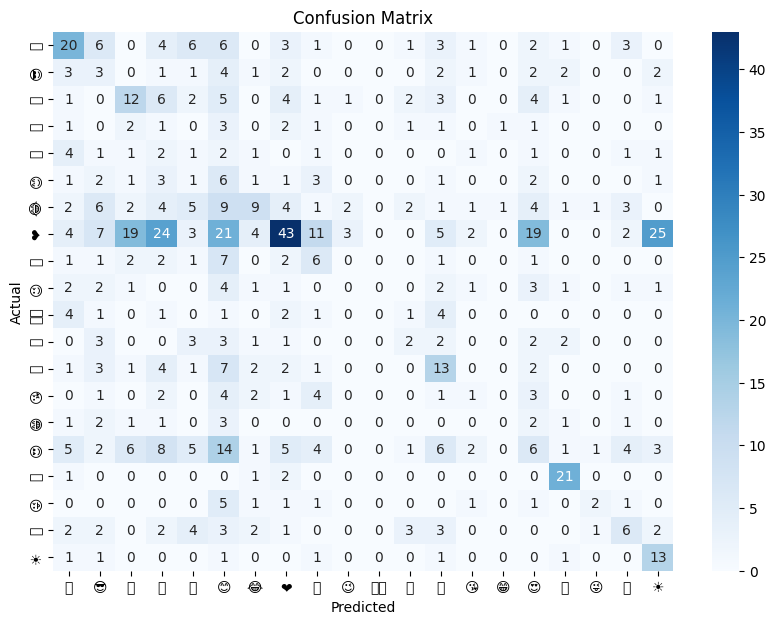

In [20]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Classification Report:\n", classification_report(y_test, predictions, labels=list(classes), zero_division=0))
print("Accuracy:", accuracy_score(y_test, predictions))

# Plot confusion matrix
cm = confusion_matrix(y_test, predictions, labels=list(classes))
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')

In [21]:
save_results(y_test, predictions, list(classes), filename="/home/v25/ippa6201/cicle-evaluation/semeval-18/results/predictions/semeval-18-ministral-3b-fewshot-contriever-2.0k-samples-8-shots.json")

Results saved to: '/home/v25/ippa6201/cicle-evaluation/semeval-18/results/predictions/semeval-18-ministral-3b-fewshot-contriever-2.0k-samples-8-shots.json'


In [22]:
save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="/home/v25/ippa6201/cicle-evaluation/semeval-18/results/lengths/semeval-18-ministral-3b-fewshot-contriever-2.0k-samples-8-shots.json")

Prompt length statistics saved to: '/home/v25/ippa6201/cicle-evaluation/semeval-18/results/lengths/semeval-18-ministral-3b-fewshot-contriever-2.0k-samples-8-shots.json'
